In [1]:
# ¿Qué tiempo medio en cola se espera el próximo mes en la red 800 de SSA y cuál es el riesgo de que la congestión aumente?

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")

activity_dir = Path("..")
data_dir = activity_dir / "data"
submission_dir = activity_dir / "submission"

In [2]:
# Las fuentes separan el resultado de congestión de sus señales operativas; se conservan ambas para que el pronóstico no dependa de una variable inventada.

speed = pd.read_csv(data_dir / "ssa_800_average_speed_to_answer.csv.gz")
workload = pd.read_csv(data_dir / "ssa_800_call_volume_and_busy_rate.csv.gz")

speed.columns = speed.columns.str.strip()
workload.columns = workload.columns.str.strip()

speed.head(3), workload.head(3)

(   FISCAL YEAR     MONTH AVERAGE SPEED TO ANSWER (SECONDS)
 0         2007   OCTOBER                               263
 1         2007  NOVEMBER                               334
 2         2007  DECEMBER                               369,
    FISCAL YEAR     MONTH  \
 0         2009   OCTOBER   
 1         2009  NOVEMBER   
 2         2009  DECEMBER   
 
   NUMBER OF CALLS OFFERED TO CUSTOMER SERVICE REPRESENTATIVES  \
 0                                          5,249,897            
 1                                          4,331,549            
 2                                          6,323,839            
 
   NUMBER OF BUSY CALLS CUSTOMER SERVICE REPRESENTATIVE BUSY RATE  
 0              577,341                                    11.00%  
 1              545,191                                    12.60%  
 2            1,801,396                                    28.50%  )

In [3]:
# El año fiscal de SSA empieza en octubre; reconstruir la fecha evita desplazar artificialmente los picos de congestión.

month_numbers = {
    "JANUARY": 1, "FEBRUARY": 2, "MARCH": 3, "APRIL": 4,
    "MAY": 5, "JUNE": 6, "JULY": 7, "AUGUST": 8,
    "SEPTEMBER": 9, "OCTOBER": 10, "NOVEMBER": 11, "DECEMBER": 12,
}

def fiscal_month_to_date(frame):
    frame = frame.copy()
    frame["MONTH"] = frame["MONTH"].str.strip().str.upper()
    frame = frame[frame["MONTH"].isin(month_numbers)].copy()
    frame["month_number"] = frame["MONTH"].map(month_numbers)
    frame["calendar_year"] = np.where(
        frame["month_number"] >= 10,
        frame["FISCAL YEAR"] - 1,
        frame["FISCAL YEAR"],
    )
    frame["date"] = pd.to_datetime(
        dict(year=frame["calendar_year"], month=frame["month_number"], day=1)
    )
    return frame

speed = fiscal_month_to_date(speed)
workload = fiscal_month_to_date(workload)

speed["average_speed_seconds"] = pd.to_numeric(
    speed["AVERAGE SPEED TO ANSWER (SECONDS)"].astype(str).str.replace(",", ""),
    errors="coerce",
)
workload["calls_offered"] = pd.to_numeric(
    workload["NUMBER OF CALLS OFFERED TO CUSTOMER SERVICE REPRESENTATIVES"].astype(str).str.replace(",", ""),
    errors="coerce",
)
workload["busy_rate"] = pd.to_numeric(
    workload["CUSTOMER SERVICE REPRESENTATIVE BUSY RATE"].astype(str).str.replace("%", ""),
    errors="coerce",
) / 100

congestion = speed[["date", "average_speed_seconds"]].merge(
    workload[["date", "calls_offered", "busy_rate"]],
    on="date",
    how="inner",
).dropna().sort_values("date").reset_index(drop=True)

congestion[["date", "average_speed_seconds", "calls_offered", "busy_rate"]].tail()

,date,average_speed_seconds,calls_offered,busy_rate
205,2025-11-01,512.0,3516965.0,0.002
206,2025-12-01,707.0,4718127.0,0.024
207,2026-01-01,664.0,5127423.0,0.012
208,2026-02-01,498.0,4439953.0,0.003
209,2026-03-01,421.0,4677380.0,0.000


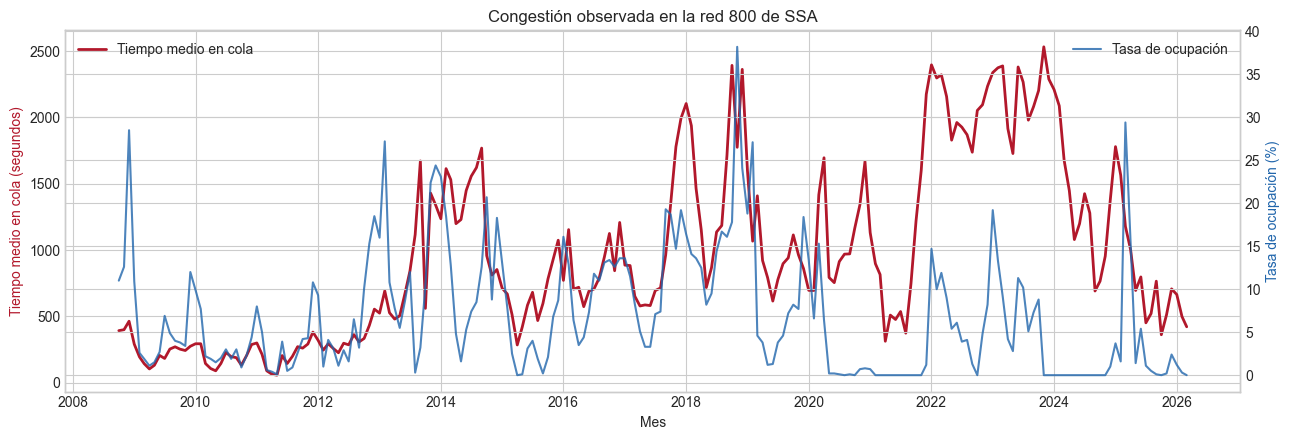

In [4]:
# La figura conecta la consecuencia para quien llama con las señales observables de carga; una relación no prueba por sí sola causalidad.

figure, axis_left = plt.subplots(figsize=(13, 4.5))
axis_right = axis_left.twinx()
axis_left.plot(
    congestion["date"], congestion["average_speed_seconds"],
    color="#b2182b", linewidth=2, label="Tiempo medio en cola",
)
axis_right.plot(
    congestion["date"], congestion["busy_rate"] * 100,
    color="#2166ac", linewidth=1.5, alpha=0.8, label="Tasa de ocupación",
)
axis_left.set_title("Congestión observada en la red 800 de SSA")
axis_left.set_xlabel("Mes")
axis_left.set_ylabel("Tiempo medio en cola (segundos)", color="#b2182b")
axis_right.set_ylabel("Tasa de ocupación (%)", color="#2166ac")
axis_left.legend(loc="upper left")
axis_right.legend(loc="upper right")
figure.tight_layout()
plt.show()

In [5]:
# El pronóstico de un mes usa solo el estado conocido al cerrar el mes anterior; así no se filtra información del futuro.

for column in ("average_speed_seconds", "calls_offered", "busy_rate"):
    congestion[f"{column}_lag_1"] = congestion[column].shift(1)

congestion["month"] = congestion["date"].dt.month.astype(str)
model_data = congestion.dropna().copy()

# La última anualidad observada se reserva íntegramente para evaluar un año de decisiones mensuales.
evaluation_months = 12
training = model_data.iloc[:-evaluation_months].copy()
evaluation = model_data.iloc[-evaluation_months:].copy()

features = [
    "average_speed_seconds_lag_1",
    "calls_offered_lag_1",
    "busy_rate_lag_1",
    "month",
]
target = "average_speed_seconds"

training[["date", *features, target]].tail()

,date,average_speed_seconds_lag_1,calls_offered_lag_1,busy_rate_lag_1,month,average_speed_seconds
193,2024-11-01,765.0,4427324.0,0.000,11,954.0
194,2024-12-01,954.0,3914980.0,0.000,12,1379.0
195,2025-01-01,1379.0,4977088.0,0.010,1,1780.0
196,2025-02-01,1780.0,6075969.0,0.037,2,1565.0
197,2025-03-01,1565.0,5219658.0,0.016,3,1179.0


In [6]:
# La línea base estacional pregunta si el modelo aporta más que repetir el tiempo observado en el mismo mes del año anterior.

seasonal_history = dict(zip(congestion["date"], congestion["average_speed_seconds"]))
def seasonal_naive(date):
    return seasonal_history.get(date - pd.DateOffset(years=1), np.nan)

evaluation["seasonal_naive_seconds"] = evaluation["date"].map(seasonal_naive)

evaluation[["date", target, "seasonal_naive_seconds"]]

,date,average_speed_seconds,seasonal_naive_seconds
198,2025-04-01,1002.0,1448.0
199,2025-05-01,695.0,1079.0
200,2025-06-01,797.0,1199.0
201,2025-07-01,451.0,1425.0
202,2025-08-01,521.0,1279.0
203,2025-09-01,765.0,691.0
204,2025-10-01,361.0,765.0
205,2025-11-01,512.0,954.0
206,2025-12-01,707.0,1379.0
207,2026-01-01,664.0,1780.0


In [7]:
# La regresión regularizada conserva una explicación directa: el nivel previo, la demanda previa, la ocupación previa y el mes pueden anticipar la congestión.

numeric_features = features[:-1]
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("month", OneHotEncoder(handle_unknown="ignore"), ["month"]),
    ]
)
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regression", Ridge(alpha=5.0)),
])
model.fit(training[features], training[target])
evaluation["operational_forecast_seconds"] = model.predict(evaluation[features])

evaluation[["date", target, "seasonal_naive_seconds", "operational_forecast_seconds"]]

,date,average_speed_seconds,seasonal_naive_seconds,operational_forecast_seconds
198,2025-04-01,1002.0,1448.0,1044.283423
199,2025-05-01,695.0,1079.0,899.912616
200,2025-06-01,797.0,1199.0,795.916704
201,2025-07-01,451.0,1425.0,867.850565
202,2025-08-01,521.0,1279.0,465.936907
203,2025-09-01,765.0,691.0,600.661090
204,2025-10-01,361.0,765.0,786.019873
205,2025-11-01,512.0,954.0,529.591689
206,2025-12-01,707.0,1379.0,716.886153
207,2026-01-01,664.0,1780.0,641.593945


/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


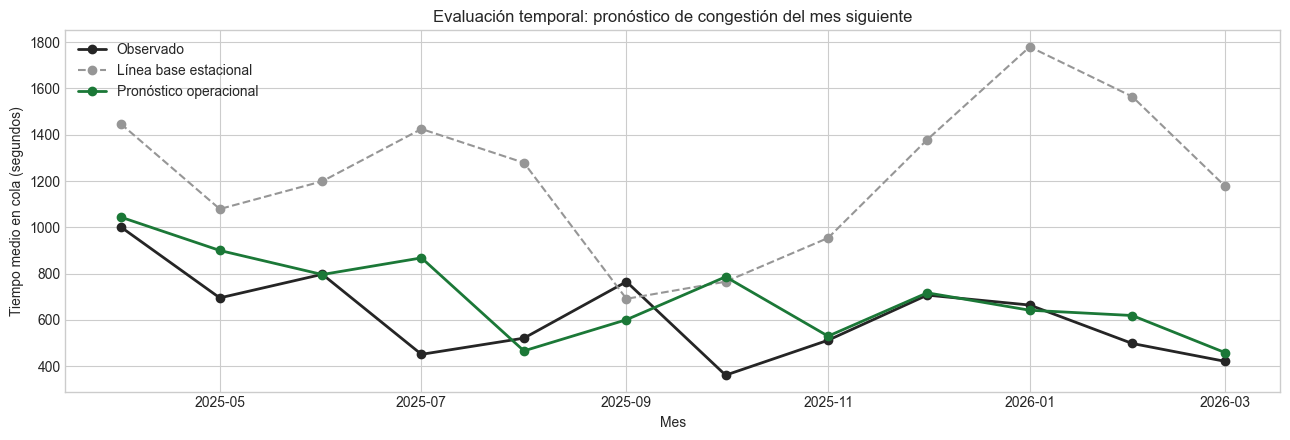

,model,mae_seconds,rmse_seconds
0,Línea base estacional,624.8,695.5
1,Regresión operacional rezagada,126.5,192.6


In [8]:
# La comparación temporal decide si las señales operativas mejoran una base que respeta la estacionalidad.

metrics = pd.DataFrame([
    {
        "model": "Línea base estacional",
        "mae_seconds": mean_absolute_error(evaluation[target], evaluation["seasonal_naive_seconds"]),
        "rmse_seconds": mean_squared_error(evaluation[target], evaluation["seasonal_naive_seconds"], squared=False),
    },
    {
        "model": "Regresión operacional rezagada",
        "mae_seconds": mean_absolute_error(evaluation[target], evaluation["operational_forecast_seconds"]),
        "rmse_seconds": mean_squared_error(evaluation[target], evaluation["operational_forecast_seconds"], squared=False),
    },
]).round(1)

figure, axis = plt.subplots(figsize=(13, 4.5))
axis.plot(evaluation["date"], evaluation[target], marker="o", linewidth=2, color="#252525", label="Observado")
axis.plot(evaluation["date"], evaluation["seasonal_naive_seconds"], marker="o", linestyle="--", color="#969696", label="Línea base estacional")
axis.plot(evaluation["date"], evaluation["operational_forecast_seconds"], marker="o", linewidth=2, color="#1b7837", label="Pronóstico operacional")
axis.set_title("Evaluación temporal: pronóstico de congestión del mes siguiente")
axis.set_xlabel("Mes")
axis.set_ylabel("Tiempo medio en cola (segundos)")
axis.legend()
figure.tight_layout()
plt.show()

metrics

In [9]:
# La evidencia deja disponible la respuesta, el contraste y los supuestos para discutir qué puede —y qué no puede— sostener el pronóstico.

forecast = evaluation[[
    "date", "average_speed_seconds", "calls_offered", "busy_rate",
    "seasonal_naive_seconds", "operational_forecast_seconds",
]].rename(columns={
    "average_speed_seconds": "observed_average_speed_seconds",
    "calls_offered": "observed_calls_offered",
    "busy_rate": "observed_busy_rate",
})

figure.savefig(submission_dir / "congestion_forecast.png", dpi=150, bbox_inches="tight")
forecast.to_csv(submission_dir / "congestion_forecast.csv", index=False)
metrics.to_csv(submission_dir / "model_metrics.csv", index=False)

assumptions = {
    "question": "What average queue time should be expected next month in SSA's 800 network?",
    "forecast_horizon": "One month ahead, evaluated for the final 12 observed months.",
    "target": "Monthly Average Speed to Answer in seconds.",
    "signals": "Prior-month queue time, calls offered, representative busy rate, and month of year.",
    "baseline": "Same month of the previous year.",
    "limitations": [
        "The data are aggregate monthly national observations, not individual calls.",
        "The model forecasts congestion; it does not estimate the number of agents or optimize staffing.",
        "A shock that changes operations can invalidate a model trained on previous months.",
    ],
}
(submission_dir / "model_assumptions.json").write_text(
    json.dumps(assumptions, indent=2) + "\n"
)

forecast.tail(), metrics

(          date  observed_average_speed_seconds  observed_calls_offered  \
 205 2025-11-01                           512.0               3516965.0   
 206 2025-12-01                           707.0               4718127.0   
 207 2026-01-01                           664.0               5127423.0   
 208 2026-02-01                           498.0               4439953.0   
 209 2026-03-01                           421.0               4677380.0   
 
      observed_busy_rate  seasonal_naive_seconds  operational_forecast_seconds  
 205               0.002                   954.0                    529.591689  
 206               0.024                  1379.0                    716.886153  
 207               0.012                  1780.0                    641.593945  
 208               0.003                  1565.0                    618.819867  
 209               0.000                  1179.0                    458.955560  ,
                             model  mae_seconds  rmse_seconds

In [10]:
# ¿La ventaja de la regresión operacional sobre la línea base es estable, o depende de dónde cayó el único corte de evaluación?

from sklearn.model_selection import TimeSeriesSplit


def build_operational_pipeline():
    return Pipeline([
        ("preprocessor", ColumnTransformer(
            transformers=[
                ("numeric", StandardScaler(), numeric_features),
                ("month", OneHotEncoder(handle_unknown="ignore"), ["month"]),
            ]
        )),
        ("regression", Ridge(alpha=5.0)),
    ])


n_rolling_origins = 24
rolling_splitter = TimeSeriesSplit(n_splits=n_rolling_origins, test_size=1)
evaluation_dates = set(evaluation["date"])

rolling_rows = []
for train_positions, test_position in rolling_splitter.split(model_data):
    origin_training = model_data.iloc[train_positions]
    origin_row = model_data.iloc[test_position]
    origin_date = origin_row["date"].iloc[0]
    actual_value = origin_row[target].iloc[0]

    origin_model = build_operational_pipeline()
    origin_model.fit(origin_training[features], origin_training[target])
    operational_forecast = origin_model.predict(origin_row[features])[0]
    seasonal_forecast = seasonal_naive(origin_date)

    for model_name, forecast_value in [
        ("Línea base estacional", seasonal_forecast),
        ("Regresión operacional rezagada", operational_forecast),
    ]:
        rolling_rows.append({
            "origin": origin_date,
            "model": model_name,
            "forecast": forecast_value,
            "actual": actual_value,
            "in_evaluation_block": origin_date in evaluation_dates,
        })

rolling_origin_errors = pd.DataFrame(rolling_rows)
rolling_origin_errors["residual"] = (
    rolling_origin_errors["actual"] - rolling_origin_errors["forecast"]
)
rolling_origin_errors["abs_error"] = rolling_origin_errors["residual"].abs()
rolling_origin_errors.tail()

,origin,model,forecast,actual,in_evaluation_block,residual,abs_error
43,2026-01-01,Regresión operacional rezagada,641.466847,664.0,True,22.533153,22.533153
44,2026-02-01,Línea base estacional,1565.000000,498.0,True,-1067.000000,1067.000000
45,2026-02-01,Regresión operacional rezagada,618.709905,498.0,True,-120.709905,120.709905
46,2026-03-01,Línea base estacional,1179.000000,421.0,True,-758.000000,758.000000
47,2026-03-01,Regresión operacional rezagada,457.622335,421.0,True,-36.622335,36.622335


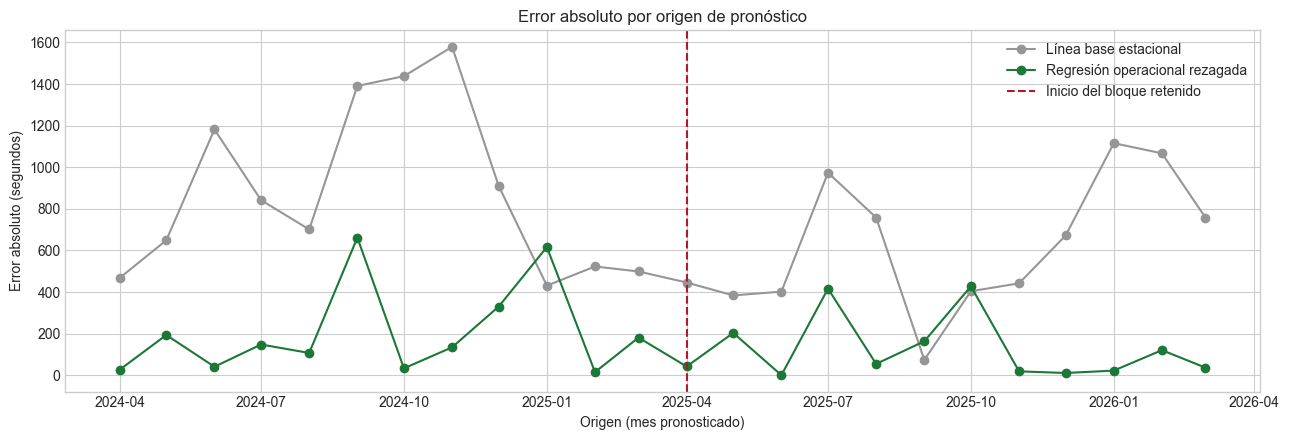

In [11]:
# La gráfica muestra si la ventaja de la regresión operacional se mantiene a lo largo de los orígenes o sólo aparece en el bloque retenido.

figure_rolling, axis_rolling = plt.subplots(figsize=(13, 4.5))
for model_name, color in [
    ("Línea base estacional", "#969696"),
    ("Regresión operacional rezagada", "#1b7837"),
]:
    series = rolling_origin_errors[rolling_origin_errors["model"] == model_name]
    axis_rolling.plot(
        series["origin"], series["abs_error"], marker="o", color=color, label=model_name
    )

block_start = evaluation["date"].min()
axis_rolling.axvline(block_start, color="#b2182b", linestyle="--", label="Inicio del bloque retenido")
axis_rolling.set_title("Error absoluto por origen de pronóstico")
axis_rolling.set_xlabel("Origen (mes pronosticado)")
axis_rolling.set_ylabel("Error absoluto (segundos)")
axis_rolling.legend()
figure_rolling.tight_layout()
plt.show()

In [12]:
# El resumen se calcula sólo sobre los 12 orígenes del bloque final, para que sea comparable con H03; los orígenes anteriores sólo alimentan el intervalo de la siguiente sección.

block_errors = rolling_origin_errors[rolling_origin_errors["in_evaluation_block"]]
rolling_summary = (
    block_errors.groupby("model")["abs_error"].agg(mae="mean", median="median").round(1)
)

paired_errors = block_errors.pivot(index="origin", columns="model", values="abs_error")
ridge_win_fraction = (
    paired_errors["Regresión operacional rezagada"] < paired_errors["Línea base estacional"]
).mean()

rolling_summary, round(ridge_win_fraction, 3)

(                                  mae  median
 model                                        
 Línea base estacional           624.8   559.0
 Regresión operacional rezagada  126.5    48.5,
 0.833)

In [13]:
# Se conserva el detalle por origen para que la estabilidad de la ventaja pueda auditarse fuera del notebook.

rolling_origin_errors.to_csv(submission_dir / "rolling_origin_errors.csv", index=False)

# Sobre los 12 orígenes del bloque final, el MAE de la regresión operacional (126.5 s)
# es consistentemente menor que el de la línea base estacional (624.8 s); Ridge gana en
# 10 de los 12 orígenes (83.3 %) y mantiene ese margen amplio también en los 12 orígenes
# anteriores al bloque (ver gráfica), no sólo en el corte oficial. La ventaja no depende
# de dónde se puso el único corte de H03: se repite mes a mes con ventana expansiva. Esta
# evaluación no sustituye la de H03, que usa el mismo bloque de doce meses; la complementa
# mostrando que ese resultado no es un artefacto de ese corte.

In [14]:
# ¿Qué tan ancho debe ser el rango alrededor del pronóstico para anticipar la presión de servicio, no sólo su valor esperado?

ridge_rolling_errors = rolling_origin_errors[
    rolling_origin_errors["model"] == "Regresión operacional rezagada"
].sort_values("origin").reset_index(drop=True)

interval_rows = []
for _, eval_row in evaluation.iterrows():
    prior_abs_errors = ridge_rolling_errors.loc[
        ridge_rolling_errors["origin"] < eval_row["date"], "abs_error"
    ]
    if len(prior_abs_errors) < 8:
        raise ValueError(
            f"Insuficientes orígenes previos para construir el intervalo de {eval_row['date'].date()}"
        )

    margin = np.percentile(prior_abs_errors, 80)
    point_forecast = eval_row["operational_forecast_seconds"]
    interval_rows.append({
        "month": eval_row["date"],
        "forecast": point_forecast,
        "lower_80": point_forecast - margin,
        "upper_80": point_forecast + margin,
        "actual": eval_row[target],
    })

forecast_intervals = pd.DataFrame(interval_rows)
forecast_intervals

,month,forecast,lower_80,upper_80,actual
0,2025-04-01,1044.283423,741.159650,1347.407196,1002.0
1,2025-05-01,899.912616,624.161769,1175.663463,695.0
2,2025-06-01,795.916704,541.561950,1050.271457,797.0
3,2025-07-01,867.850565,638.876460,1096.824670,451.0
4,2025-08-01,465.936907,135.440209,796.433606,521.0
5,2025-09-01,600.661090,295.545039,905.777140,765.0
6,2025-10-01,786.019873,506.284471,1065.755275,361.0
7,2025-11-01,529.591689,164.727196,894.456183,512.0
8,2025-12-01,716.886153,369.205557,1064.566750,707.0
9,2026-01-01,641.593945,311.097246,972.090643,664.0


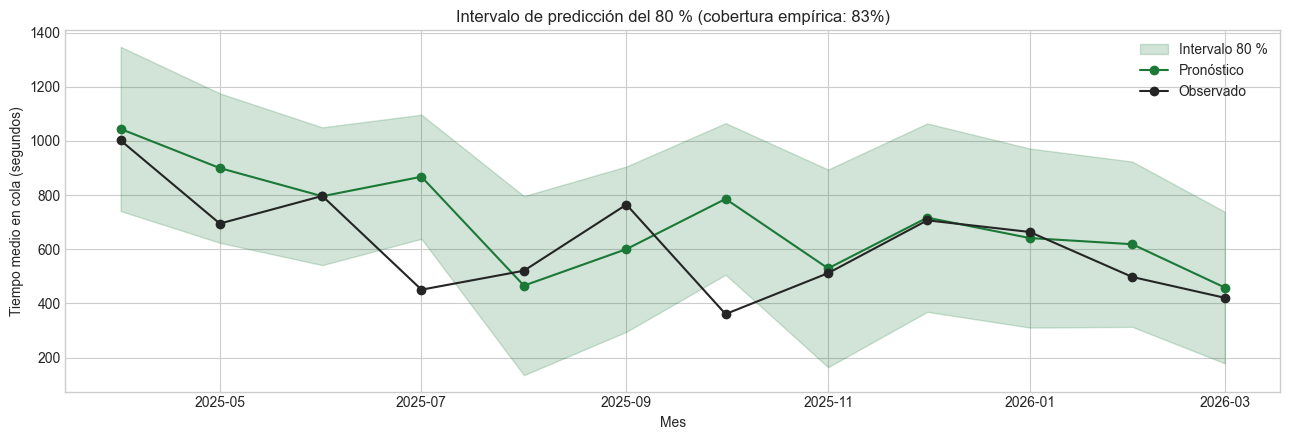

0.8333333333333334

In [15]:
# La cobertura dice qué tan seguido el valor real cayó dentro del rango que promete el intervalo, no si el pronóstico puntual acertó.

forecast_intervals["covered"] = forecast_intervals["actual"].between(
    forecast_intervals["lower_80"], forecast_intervals["upper_80"]
)
empirical_coverage = forecast_intervals["covered"].mean()

figure_interval, axis_interval = plt.subplots(figsize=(13, 4.5))
axis_interval.fill_between(
    forecast_intervals["month"],
    forecast_intervals["lower_80"],
    forecast_intervals["upper_80"],
    color="#1b7837", alpha=0.2, label="Intervalo 80 %",
)
axis_interval.plot(
    forecast_intervals["month"], forecast_intervals["forecast"],
    marker="o", color="#1b7837", label="Pronóstico",
)
axis_interval.plot(
    forecast_intervals["month"], forecast_intervals["actual"],
    marker="o", color="#252525", label="Observado",
)
axis_interval.set_title(f"Intervalo de predicción del 80 % (cobertura empírica: {empirical_coverage:.0%})")
axis_interval.set_xlabel("Mes")
axis_interval.set_ylabel("Tiempo medio en cola (segundos)")
axis_interval.legend()
figure_interval.tight_layout()
plt.show()

empirical_coverage

In [16]:
# Se conserva el intervalo y su gráfico para que la cobertura declarada pueda auditarse frente al bloque retenido.

figure_interval.savefig(submission_dir / "forecast_intervals.png", dpi=150, bbox_inches="tight")
forecast_intervals.drop(columns="covered").to_csv(
    submission_dir / "forecast_intervals.csv", index=False
)

# El intervalo del 80 % cubrió el valor real en 10 de los 12 meses evaluados (cobertura
# empírica de 83.3 %), cercano al 80 % nominal dada la poca cantidad de meses. Los dos
# meses sin cobertura (julio y octubre de 2025) ocurrieron porque la congestión bajó más
# de lo que el margen histórico de error anticipaba, no porque subiera más de lo previsto;
# el riesgo de subestimar la presión de servicio no se materializó en esos casos. El margen
# se construye con el percentil 80 del error absoluto de los orígenes móviles anteriores a
# cada mes, no con una distribución supuesta, por lo que no garantiza una cobertura exacta
# del 80 % con tan pocos meses. El intervalo informa cuánto puede desviarse el pronóstico;
# no fija una política de capacidad ni fue diseñado para optimizar personal.